<a href="https://colab.research.google.com/github/anjicx/CNHypergraph/blob/main/Histograms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')
stays = pd.read_csv("/content/drive/MyDrive/PatientData/final_one_percent_stays.csv", sep=";")
age = pd.read_csv( "/content/drive/MyDrive/PatientData/table_age.csv",sep=";",encoding="latin1")

Mounted at /content/drive


We want to see divided by genders and age groups how long these patients occure in dataset. Patients age is the age of his first visit, and numbers of years=last visit day-first visit day(how long the patient is followed in data).


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import math

In [55]:
stays = stays.merge(age, on="ag_id", how="left")#merging age group gender
stays = stays.rename(columns={"age": "age_group"})
#taking men/women nonbinary has 43261 and is not therefore included
staysHistogram = stays[["patient_no", "entry_date", "exit_date", "sex_id","age_group"]].copy()
staysHistogram = staysHistogram[staysHistogram["sex_id"].isin([1, 2])].copy()#only 1 and 2
#print(staysHistogram["sex_id"].value_counts(dropna=False).sort_index())

In [57]:
#dates to real dates
staysHistogram["entry_date"] = pd.to_datetime(stays["entry_date"])
staysHistogram["exit_date"] = pd.to_datetime(stays["exit_date"])
staysHistogram["exit_date"] = staysHistogram["exit_date"].fillna(stays["entry_date"])#if exit day is missing

#sort by patient and date
staysHistogram = staysHistogram.sort_values(["patient_no", "entry_date"])

#first and last date from patient counting

patient_years = staysHistogram.groupby("patient_no").agg(
    first_date=("entry_date", "min"),
    last_date=("exit_date", "max")
).reset_index()
#years per patient
patient_years["years_per_patient"] = (
    patient_years["last_date"] - patient_years["first_date"]
).dt.days / 365.25

#from first visit for patient get age and gender
first_visit = staysHistogram.groupby("patient_no").first().reset_index()[["patient_no", "sex_id", "age_group"]]

#one patient table
patient_data = patient_years.merge(first_visit, on="patient_no", how="left")

#se label for patient_data

patient_data["sex"] = patient_data["sex_id"].map({
    1: "Male",
    2: "Female"
})

In [65]:
import matplotlib.pyplot as plt
import numpy as np
import math

def plot_by_sex(sex_value, bin_width=2):
    sub = patient_data[patient_data["sex"] == sex_value].copy()
    age_groups = sorted(sub["age_group"].dropna().unique())

    # same bins for all subplots
    max_years = np.ceil(sub["years_per_patient"].max())
    bins = np.arange(0, max_years + bin_width, bin_width)

    n = len(age_groups)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(14, 4 * nrows),
        sharex=True,
        sharey=True
    )
    axes = np.array(axes).reshape(-1)

    for i, ag in enumerate(age_groups):
        vals = sub[sub["age_group"] == ag]["years_per_patient"].dropna()

        axes[i].hist(vals, bins=bins, color="skyblue", edgecolor="black")
        axes[i].set_title(f"{ag}")
        axes[i].set_xlabel("Years in data")
        axes[i].set_ylabel("Patients")
        axes[i].grid(axis="y", alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

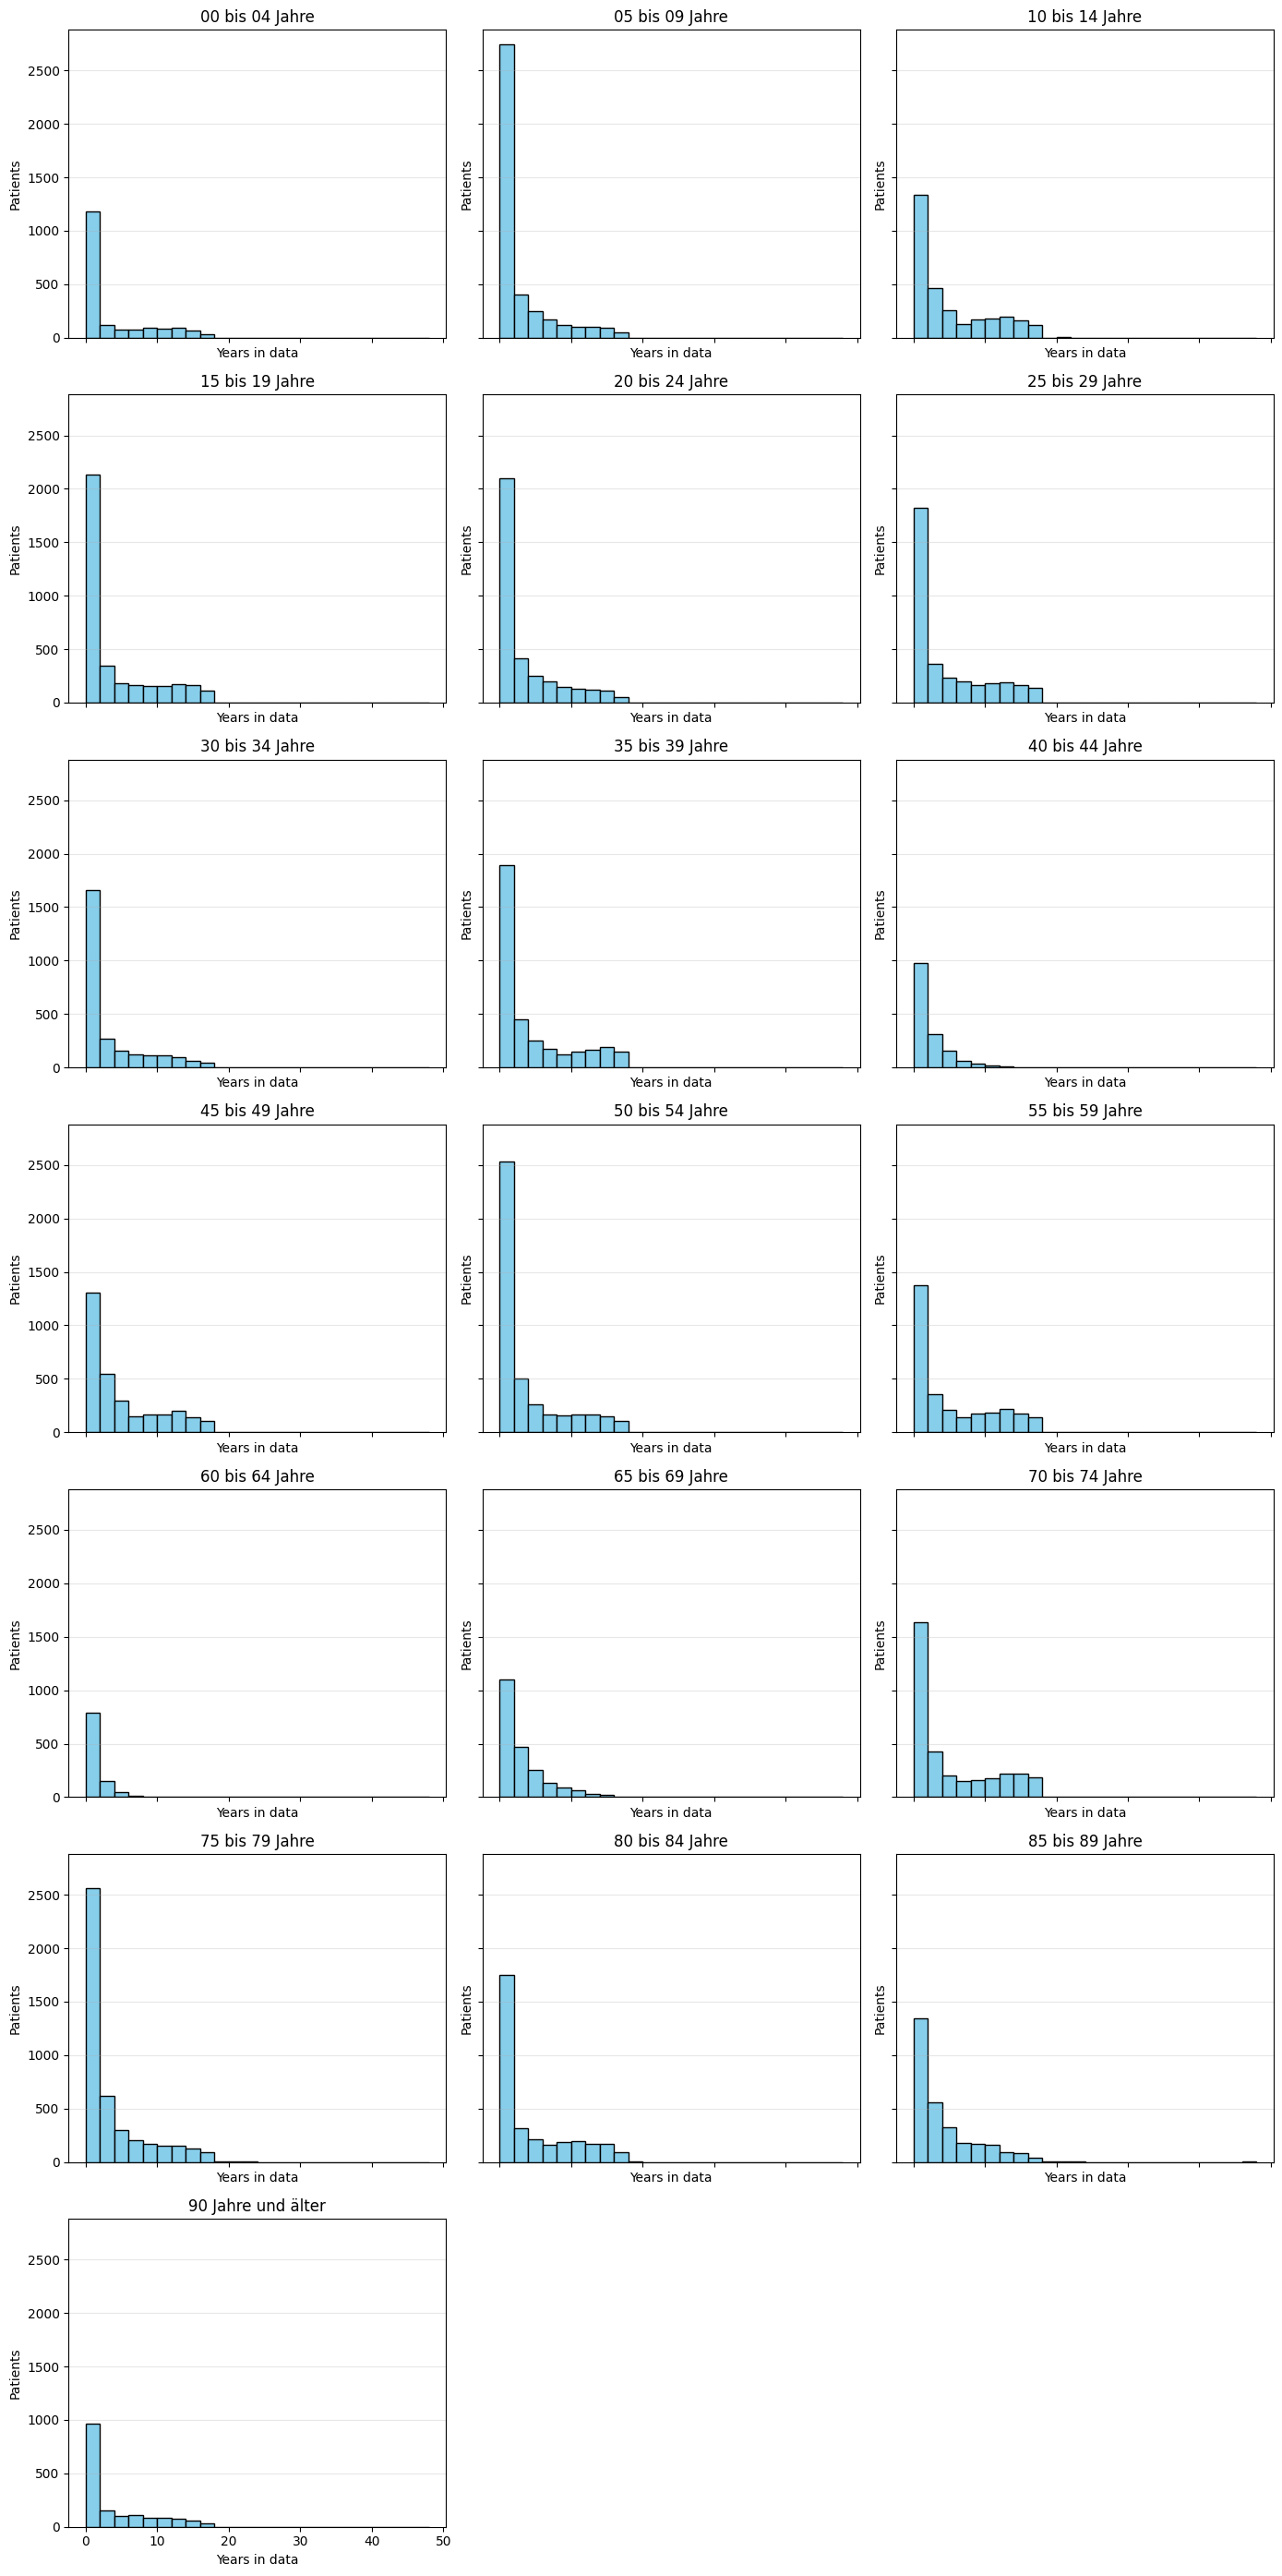

In [66]:
plot_by_sex("Female")

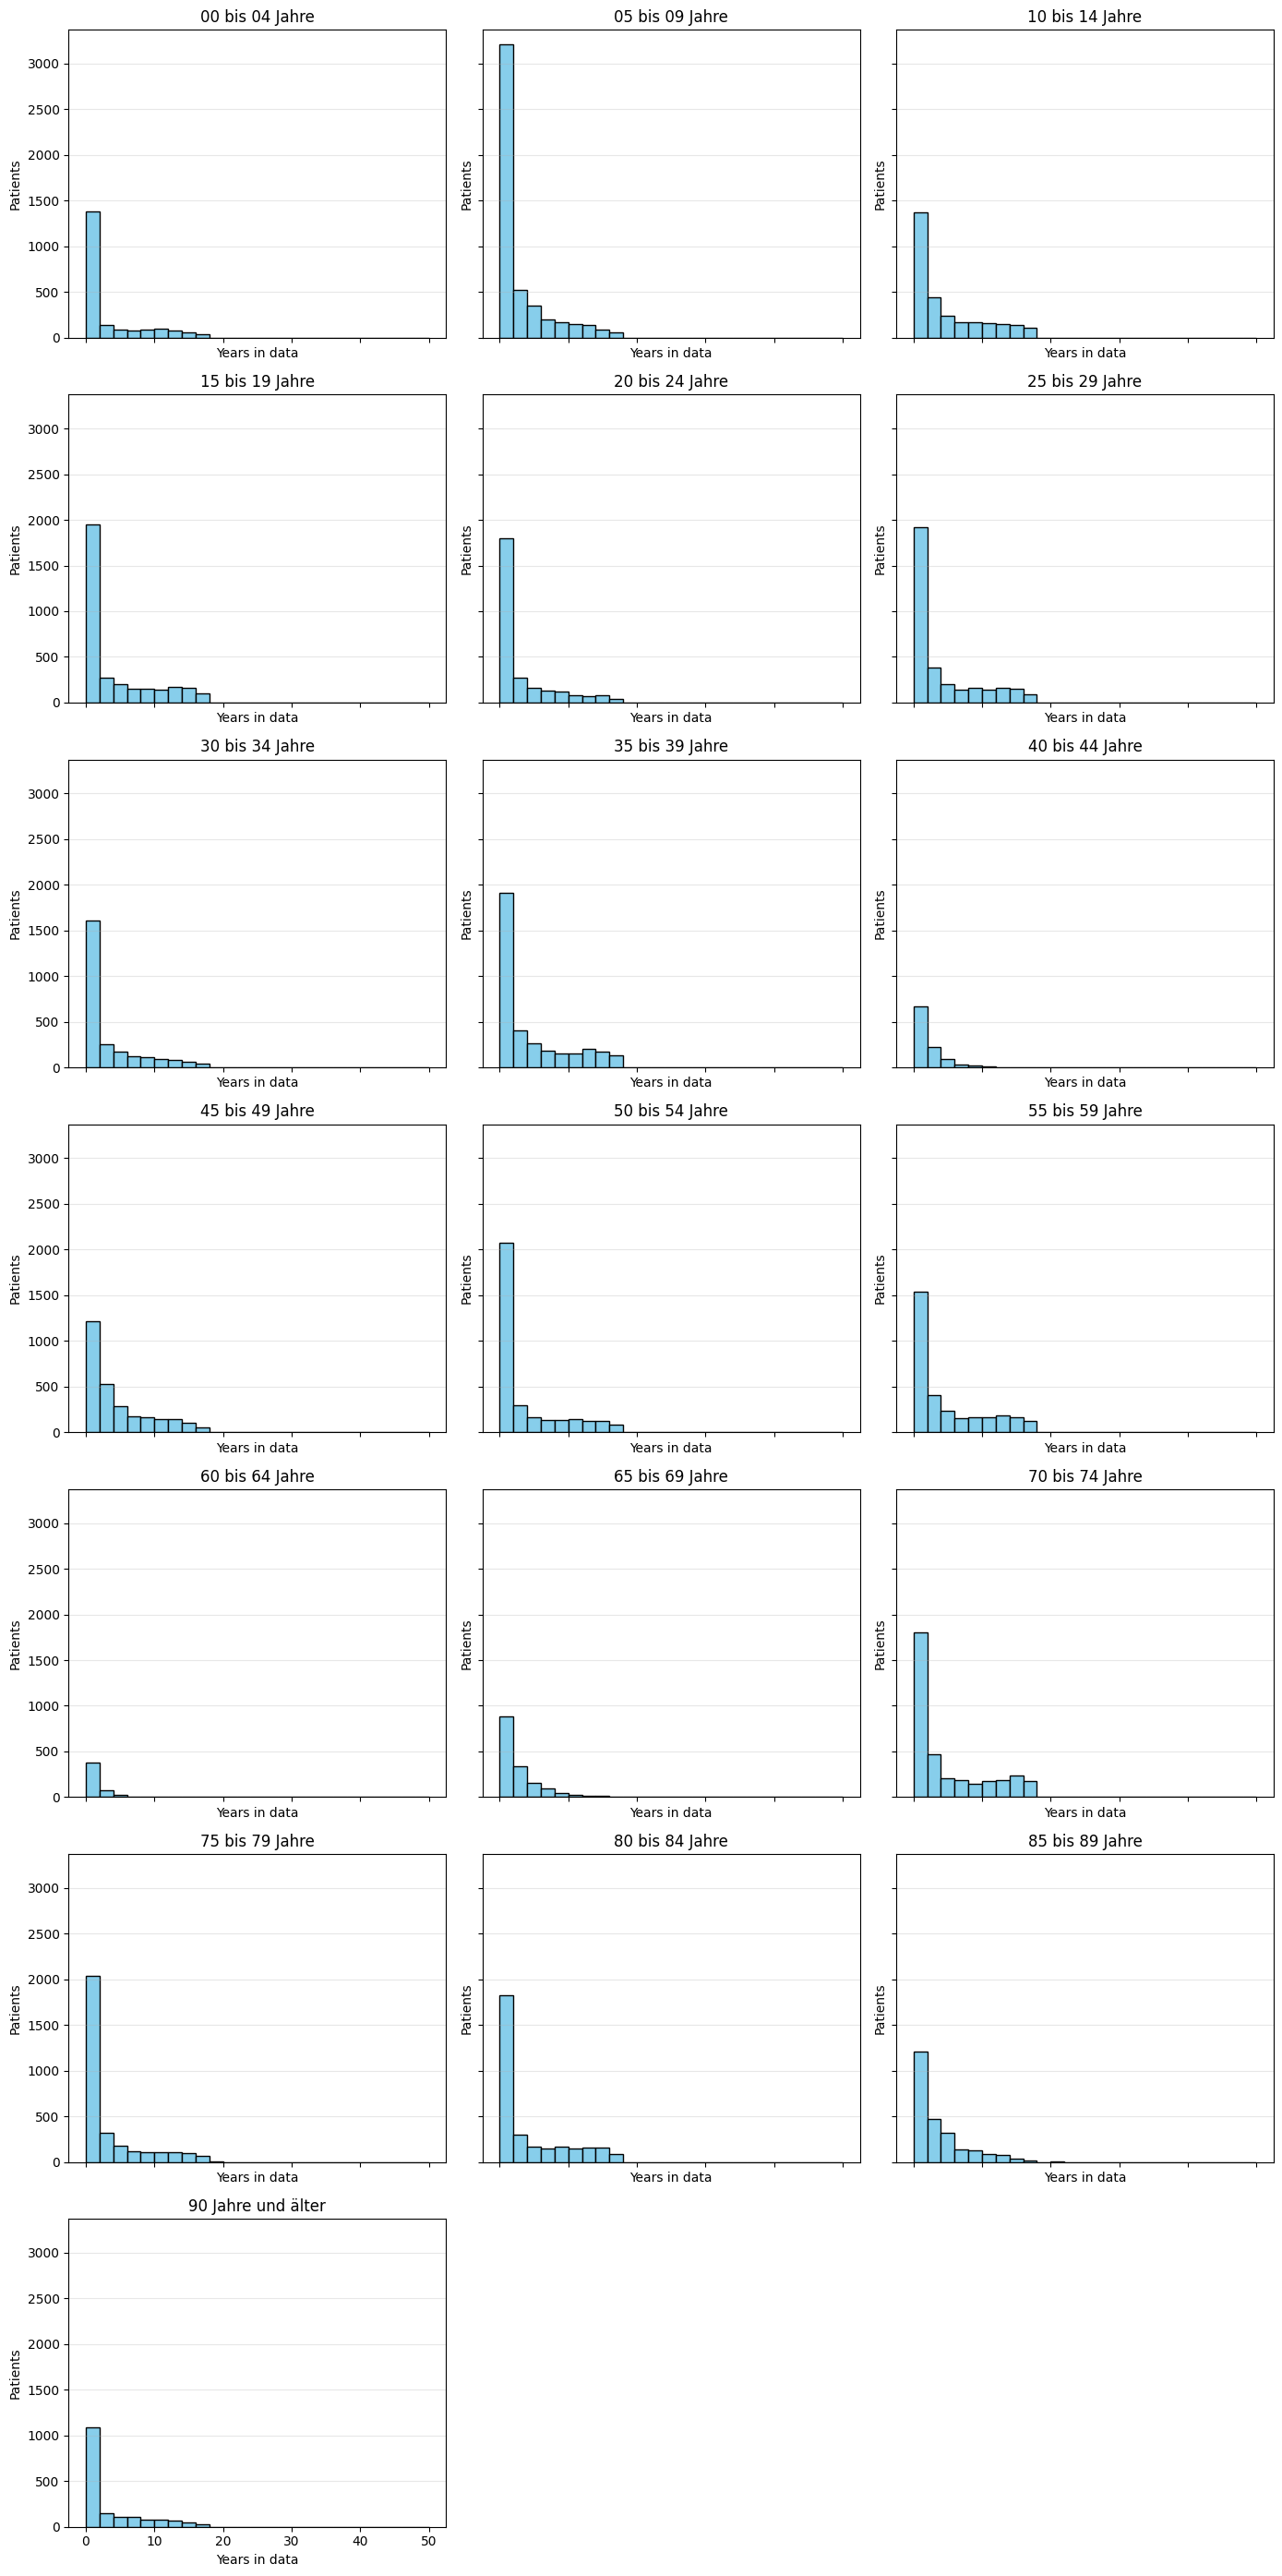

In [67]:
plot_by_sex("Male")